In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/Shared drives/Spring Analytics Showdown/Challenge + Dataset/')

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%matplotlib inline
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve, auc


In [4]:
final_df = pd.read_csv("final_df.csv")

In [5]:
final_df.head(10)

,farmer_id,crop_class_name,association,camp_name,district_name,region_name,number_seasons,agroecological_zone,initial_down_payment_value,package_cash_repayment,...,grade_b_price,grade_c_price,total_weight,grade_a_weight,grade_b_weight,grade_c_weight,total_net_weight,grade_a_cash_value,grade_b_cash_value,grade_c_cash_value
0,2504,Soy Bean,GNA Farmer,Ng'ongwe,Kasenengwa,Kasenengwa,3,IIa,200.0,0,...,14,12,550,550,0,0,350,5250,0,0
1,2511,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,3,IIa,100.0,0,...,14,12,1139,1139,0,0,1039,15585,0,0
2,2512,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,2,IIa,100.0,0,...,14,12,805,805,0,0,705,10575,0,0
3,2513,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,1,IIa,100.0,0,...,14,12,344,344,0,0,244,3660,0,0
4,2516,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,5,IIa,200.0,0,...,14,12,1536,1536,0,0,1336,20040,0,0
5,2517,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,5,IIa,300.0,0,...,14,12,3993,3906,0,87,3593,52590,0,1044
6,2518,Soy Bean,GNA Farmer,Mzapawi,Kasenengwa,Kasenengwa,5,IIa,100.0,0,...,14,12,146,146,0,0,46,690,0,0
7,2538,Soy Bean,GNA Farmer,Kasenengwa,Kasenengwa,Kasenengwa,2,IIa,100.0,0,...,15,14,300,300,0,0,200,3400,0,0
8,2539,Soy Bean,GNA Farmer,Kasenengwa,Kasenengwa,Kasenengwa,1,IIa,100.0,0,...,15,14,630,630,0,0,530,9010,0,0
9,2540,Soy Bean,GNA Farmer,Kasenengwa,Kasenengwa,Kasenengwa,5,IIa,200.0,0,...,14,12,1450,1450,0,0,1250,18750,0,0


In [6]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18947 entries, 0 to 18946
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   farmer_id                   18947 non-null  int64  
 1   crop_class_name             18947 non-null  object 
 2   association                 18947 non-null  object 
 3   camp_name                   18947 non-null  object 
 4   district_name               18947 non-null  object 
 5   region_name                 18947 non-null  object 
 6   number_seasons              18947 non-null  int64  
 7   agroecological_zone         18947 non-null  object 
 8   initial_down_payment_value  18947 non-null  float64
 9   package_cash_repayment      18947 non-null  int64  
 10  package_in_kind_repayment   18947 non-null  int64  
 11  package_hectares            18947 non-null  float64
 12  fertilizer                  18947 non-null  float64
 13  fungicide                   189

In [7]:
target = 'total_net_weight'

num_features = [
 'number_seasons',
 'initial_down_payment_value',
 'package_cash_repayment',
 'package_in_kind_repayment',
 'package_hectares',
 'fertilizer',
 'fungicide',
 'gypsum',
 'inoculant',
 'insecticide',
 'lime',
 'seed_guard',
 'grade_a_price',
 'grade_b_price',
 'grade_c_price',
 'grade_a_cash_value',
 'grade_b_cash_value',
 'grade_c_cash_value'
]

cat_features = [
   'crop_class_name',
   'association',
   'camp_name',
   'district_name',
   'region_name'
]

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [9]:
X = final_df[num_features + cat_features]
y = final_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Redefine preprocessor to ensure it uses the correct column names
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# Create a pipeline with the (now correctly defined) preprocessor and Random Forest Regressor
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators = 100, random_state=42, oob_score = True))
])

# Train the Random Forest Regressor model
model_rf.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['number_seasons',
                                                   'initial_down_payment_value',
                                                   'package_cash_repayment',
                                                   'package_in_kind_repayment',
                                                   'package_hectares',
                                                   'fertilizer', 'fungicide',
                                                   'gypsum', 'inoculant',
                                                   'insecticide', 'lime',
                                                   'seed_guard',
                                                   'grade_a_price',
                                                   'grade_b_price',
                                                   'grade_c_price',
                                                   'grade_a_cash_value',
                                                   'grade_b_cash_value',
                                                   'grade_c_cash_value']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop_class_name',
                                                   'association', 'camp_name',
                                                   'district_name',
                                                   'region_name'])])),
                ('regressor',
                 RandomForestRegressor(oob_score=True, random_state=42))])

Random Forest Regressor model trained successfully!


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

print("Out-of-Bag Score:", model_rf.named_steps['regressor'].oob_score_)

y_pred = model_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Out-of-Bag Score: 0.951444316007479
Mean Squared Error: 12671.104406754617
R-squared: 0.9637194576383608


Top 20 Feature Importances:
                        Feature  Importance
15           grade_a_cash_value    0.591441
17           grade_c_cash_value    0.124237
16           grade_b_cash_value    0.118265
12                grade_a_price    0.094562
4              package_hectares    0.015132
8                     inoculant    0.011404
14                grade_c_price    0.010119
13                grade_b_price    0.007221
1    initial_down_payment_value    0.004171
146          region_name_Malawi    0.003042
0                number_seasons    0.002659
74             camp_name_Malawi    0.002356
3     package_in_kind_repayment    0.002229
6                     fungicide    0.002209
125        district_name_Malawi    0.001615
9                   insecticide    0.001485
80            camp_name_Mpula 1    0.001408
21     crop_class_name_Soy Bean    0.001006
22   crop_class_name_Sugar bean    0.000695
149        region_name_Northern    0.000404


<Figure size 1200x800 with 0 Axes>

<Axes: xlabel='Importance', ylabel='Feature'>

Text(0.5, 1.0, 'Top 20 Feature Importances from Random Forest Regressor')

Text(0.5, 0, 'Importance')

Text(0, 0.5, 'Feature Name')

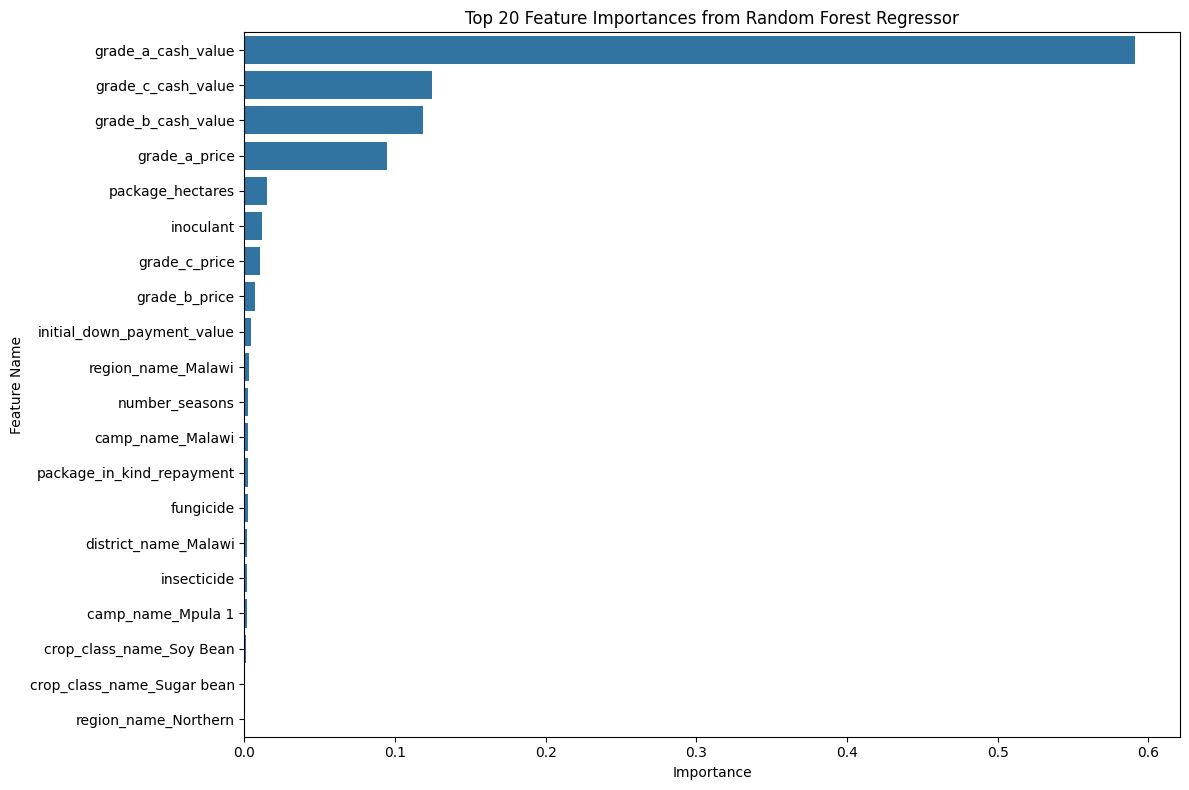

In [12]:
# Get feature importances from the Random Forest Regressor
feature_importances = model_rf.named_steps['regressor'].feature_importances_

# Get feature names from the preprocessor
# Numerical features are straightforward
num_feature_names = num_features

# Categorical features are one-hot encoded, so we need to get their new names
# The preprocessor is already fitted within the pipeline
cat_transformer = model_rf.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_transformer.get_feature_names_out(cat_features)

# Combine all feature names
all_feature_names = list(num_feature_names) + list(cat_feature_names)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top 20 features
print("Top 20 Feature Importances:")
print(importance_df.head(20))

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor # Import XGBoost Regressor

# Create a new pipeline with the preprocessor and XGBoost Regressor
# Reusing the 'preprocessor' defined earlier
model_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42, n_jobs=-1)) # Initialize XGBoost Regressor
])

# Define the parameter distribution for RandomizedSearchCV for XGBoost
param_dist_xgb = {
    'regressor__n_estimators': [100, 200, 300, 400, 500], # Number of boosting rounds
    'regressor__max_depth': [3, 4, 5, 6, 7, 8, 9, 10], # Maximum depth of a tree
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'regressor__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'regressor__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'regressor__gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'regressor__reg_alpha': [0, 0.001, 0.005, 0.01, 0.05, 0.1],
    'regressor__reg_lambda': [1, 5, 10, 20, 50]
}

# Create a RandomizedSearchCV object for XGBoost
random_search_xgb = RandomizedSearchCV(
    estimator=model_xgb, # Our new XGBoost pipeline
    param_distributions=param_dist_xgb,
    n_iter=50, # Number of parameter settings that are sampled. Adjust as needed.
    cv=5, # 5-fold cross-validation
    verbose=2, # Outputs progress of the search
    random_state=42,
    n_jobs=-1, # Use all available cores
    scoring='r2' # Use R-squared as the scoring metric
)

# Fit RandomizedSearchCV to the training data
print("Fitting RandomizedSearchCV for XGBoost Regressor...")
random_search_xgb.fit(X_train, y_train)

print("\nRandomized Search CV completed for XGBoost!")
print("Best parameters found:", random_search_xgb.best_params_)
print("Best R-squared score:", random_search_xgb.best_score_)

# You can also get the best estimator found by RandomizedSearchCV
best_xgb_model = random_search_xgb.best_estimator_

# Evaluate the best model on the test set
y_pred_best_xgb = best_xgb_model.predict(X_test)

mse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb)
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print("Mean Squared Error (Best XGBoost Model):", mse_best_xgb)
print("R-squared (Best XGBoost Model):", r2_best_xgb)


Fitting RandomizedSearchCV for XGBoost Regressor...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['number_seasons',
                                                                                'initial_down_payment_value',
                                                                                'package_cash_repayment',
                                                                                'package_in_kind_repayment',
                                                                                'package_hectares',
                                                                                'fertilizer',
                                                                                'fungicide',
                                                                                'gypsum',
                                                                                'inoculant',
                                                                                'insecticide',
                                                                                'lime',
                                                                                'seed_guard',
                                                                                'grade_a_price',
                                                                                'grade_b_pric...
                                        'regressor__gamma': [0, 0.1, 0.2, 0.3,
                                                             0.4],
                                        'regressor__learning_rate': [0.01, 0.05,
                                                                     0.1, 0.2,
                                                                     0.3],
                                        'regressor__max_depth': [3, 4, 5, 6, 7,
                                                                 8, 9, 10],
                                        'regressor__n_estimators': [100, 200,
                                                                    300, 400,
                                                                    500],
                                        'regressor__reg_alpha': [0, 0.001,
                                                                 0.005, 0.01,
                                                                 0.05, 0.1],
                                        'regressor__reg_lambda': [1, 5, 10, 20,
                                                                  50],
                                        'regressor__subsample': [0.6, 0.7, 0.8,
                                                                 0.9, 1.0]},
                   random_state=42, scoring='r2', verbose=2)


Randomized Search CV completed for XGBoost!
Best parameters found: {'regressor__subsample': 0.9, 'regressor__reg_lambda': 1, 'regressor__reg_alpha': 0.1, 'regressor__n_estimators': 300, 'regressor__max_depth': 4, 'regressor__learning_rate': 0.2, 'regressor__gamma': 0.3, 'regressor__colsample_bytree': 0.7}
Best R-squared score: 0.9587549209594727
Mean Squared Error (Best XGBoost Model): 5895.07763671875
R-squared (Best XGBoost Model): 0.9831209182739258


Top 20 Feature Importances for XGBoost Model:
                        Feature  Importance
15           grade_a_cash_value    0.244030
12                grade_a_price    0.109116
17           grade_c_cash_value    0.093433
118    district_name_Kasenengwa    0.072489
16           grade_b_cash_value    0.070874
8                     inoculant    0.060393
151         region_name_Western    0.049919
22   crop_class_name_Sugar bean    0.048246
13                grade_b_price    0.043397
14                grade_c_price    0.033594
21     crop_class_name_Soy Bean    0.033194
9                   insecticide    0.033179
4              package_hectares    0.016398
1    initial_down_payment_value    0.008541
6                     fungicide    0.005568
121       district_name_Likumbi    0.005044
0                number_seasons    0.004605
143          region_name_Kapiri    0.004287
130       district_name_Mpula 1    0.003766
116    district_name_Kalumwange    0.003589


<Figure size 1200x800 with 0 Axes>

<Axes: xlabel='Importance', ylabel='Feature'>

Text(0.5, 1.0, 'Top 20 Feature Importances from XGBoost Regressor')

Text(0.5, 0, 'Importance')

Text(0, 0.5, 'Feature Name')

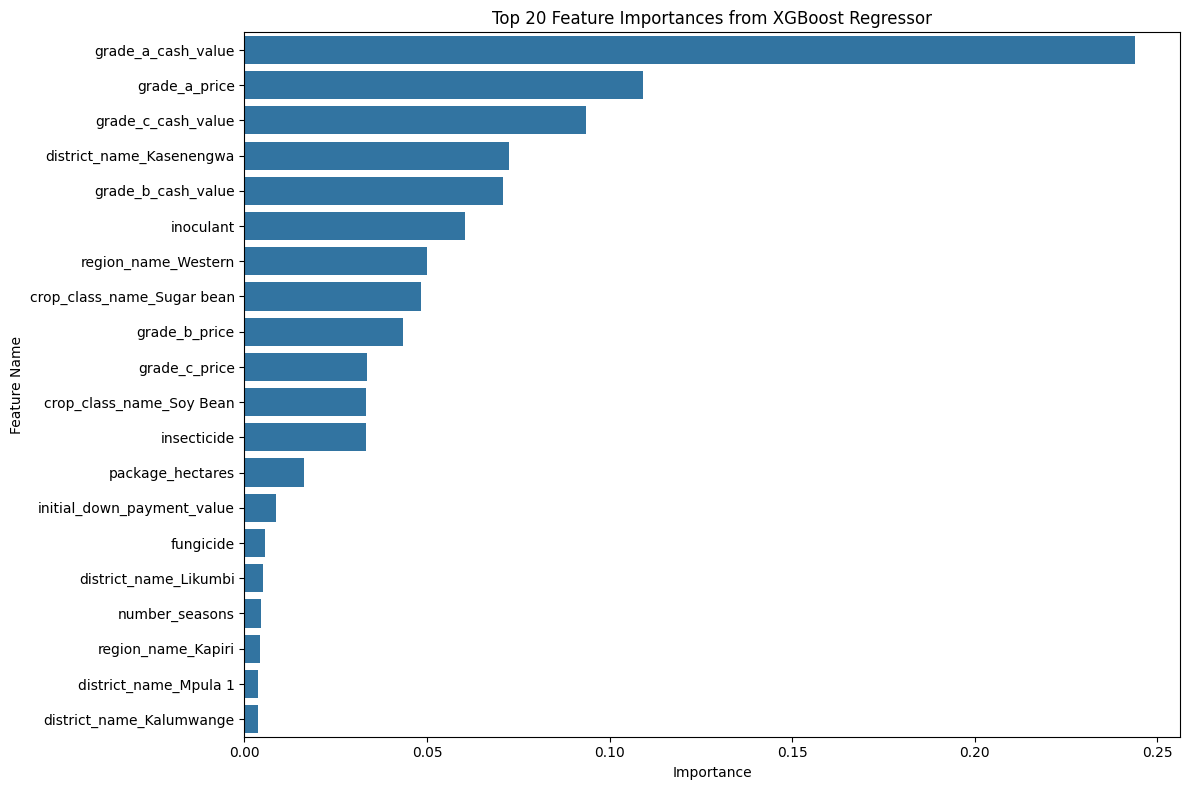

In [14]:
# Get feature importances from the best XGBoost Regressor model
# The best_xgb_model is a pipeline, and the regressor is the 'regressor' step
feature_importances_xgb = best_xgb_model.named_steps['regressor'].feature_importances_

# Get feature names from the preprocessor (reusing the logic from the previous RF model)
# Numerical features are straightforward
num_feature_names_xgb = num_features # Already defined

# Categorical features are one-hot encoded, so we need to get their new names
# The preprocessor is already fitted within the pipeline
cat_transformer_xgb = best_xgb_model.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names_xgb = cat_transformer_xgb.get_feature_names_out(cat_features)

# Combine all feature names
all_feature_names_xgb = list(num_feature_names_xgb) + list(cat_feature_names_xgb)

# Create a DataFrame for better visualization
importance_df_xgb = pd.DataFrame({
    'Feature': all_feature_names_xgb,
    'Importance': feature_importances_xgb
})

# Sort by importance
importance_df_xgb = importance_df_xgb.sort_values(by='Importance', ascending=False)

# Display the top 20 features
print("Top 20 Feature Importances for XGBoost Model:")
print(importance_df_xgb.head(20))

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_xgb.head(20))
plt.title('Top 20 Feature Importances from XGBoost Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()


In [15]:
from sklearn.metrics import mean_squared_error, r2_score

# Create a base XGBoost Regressor model pipeline
# We'll use the preprocessor defined earlier and common XGBoost parameters
base_xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators = 100, learning_rate = 0.1, random_state=42, n_jobs=-1)) # Default parameters
])

print("Fitting Base XGBoost Regressor model...")
base_xgb_model.fit(X_train, y_train)
print("Base XGBoost Regressor model trained successfully!")

# Make predictions on the test set
y_pred_base_xgb = base_xgb_model.predict(X_test)

# Evaluate the base model
mse_base_xgb = mean_squared_error(y_test, y_pred_base_xgb)
r2_base_xgb = r2_score(y_test, y_pred_base_xgb)

print("\n--- Base XGBoost Model Performance ---")
print("Mean Squared Error (Base XGBoost Model):", mse_base_xgb)
print("R-squared (Base XGBoost Model):", r2_base_xgb)

print("\n--- Tuned XGBoost Model Performance (for comparison) ---")
print("Mean Squared Error (Best XGBoost Model):", mse_best_xgb)
print("R-squared (Best XGBoost Model):", r2_best_xgb)


Fitting Base XGBoost Regressor model...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['number_seasons',
                                                   'initial_down_payment_value',
                                                   'package_cash_repayment',
                                                   'package_in_kind_repayment',
                                                   'package_hectares',
                                                   'fertilizer', 'fungicide',
                                                   'gypsum', 'inoculant',
                                                   'insecticide', 'lime',
                                                   'seed_guard',
                                                   'grade_a_price',
                                                   'grade_b_price',
                                                   'grade_c_price',
                                                   'grade_a_cash_v...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=-1,
                              num_parallel_tree=None, ...))])

Base XGBoost Regressor model trained successfully!

--- Base XGBoost Model Performance ---
Mean Squared Error (Base XGBoost Model): 8842.06640625
R-squared (Base XGBoost Model): 0.9746829271316528

--- Tuned XGBoost Model Performance (for comparison) ---
Mean Squared Error (Best XGBoost Model): 5895.07763671875
R-squared (Best XGBoost Model): 0.9831209182739258
